# Dataset 2 — Google Trends via pytrends

**Method:** Web scraping via `pytrends` (unofficial Google Trends API wrapper)  
**Output:** `data/trends_skills.csv`, `data/trends_jobtitles.csv`, `data/trends_combined.csv`  

### What this notebook does
1. Fetches Google Trends search interest for **top skills** from job listings
2. Fetches Google Trends search interest for **top job titles**
3. Compares search interest trends against **actual job listing volume** from the LinkedIn dataset
4. Exports combined data for the Streamlit dashboard

### Requirements
```
pip install pytrends
```

## 1. Installations and Setup

In [1]:
!pip install pytrends
!pip install "urllib3<2.0"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import requests
import ast
from pytrends.request import TrendReq
import warnings

from pytrends.request import TrendReq

print('Libraries loaded')

Libraries loaded


In [3]:
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='darkgrid', palette='muted')

session = requests.Session()
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept-Language': 'en-US,en;q=0.9',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
})

pytrends = TrendReq(
    hl='en-US',
    tz=360,
    timeout=(10, 25),
    retries=1,
    backoff_factor=1,
    requests_args={'headers': session.headers}
)

print('pytrends ready')

pytrends ready


## 2. Load Job Listings — Get Top Skills & Titles

In [4]:
jobs = pd.read_csv('data/cleaned_jobs.csv')
print(f'Jobs dataset: {jobs.shape}')

# Top skills from extracted_skills column 
def parse_list(val):
    if isinstance(val, list): return val
    if pd.isna(val): return []
    try: return ast.literal_eval(str(val))
    except: return []

if 'extracted_skills' in jobs.columns:
    all_skills = jobs['extracted_skills'].apply(parse_list).explode().dropna()
    top_skills = all_skills.value_counts().head(20).index.tolist()
    print(f'\nTop 20 skills from dataset:')
    print(top_skills)
else:
    # Fallback if extracted_skills not yet in CSV
    top_skills = ['python', 'sql', 'aws', 'machine learning', 'excel',
                  'docker', 'azure', 'javascript', 'tableau', 'kubernetes']
    print('extracted_skills not in CSV — using default skill list')
    print('(Re-run finals.ipynb first for better results)')

# Top job titles by listing count 
top_titles = jobs['title_clean'].value_counts().head(20).index.tolist()
print(f'\nTop job titles from dataset:')
print(top_titles[:10])

Jobs dataset: (35563, 18)

Top 20 skills from dataset:
['communication', 'excel', 'leadership', 'aws', 'customer service', 'problem solving', 'collaboration', 'presentation', 'git', 'rust', 'microsoft office', 'project management', 'scala', 'monday', 'sas', 'time management', 'teamwork', 'powerpoint', 'outlook', 'sap']

Top job titles from dataset:
['registered nurse', 'project manager', 'senior accountant', 'administrative assistant', 'staff accountant', 'customer service representative', 'executive assistant', 'account executive', 'controller', 'senior software engineer']


## 3. Define Timeframe

In [5]:
# Match timeframe to the job listings dataset
TIMEFRAME = '2023-01-01 2024-06-01'   
GEO       = 'US' # United States only

print(f'Fetching trends for: {TIMEFRAME}  |  geo: {GEO}')

Fetching trends for: 2023-01-01 2024-06-01  |  geo: US


## 4. Fetch Skill Trends from Google

Google Trends only allows **5 keywords per request**.  
We batch the top skills into groups of 5 and use a common anchor term (`python`)  
to normalise scores across batches.

In [6]:
def fetch_trends_batched(keywords, timeframe, geo, anchor='python', sleep_secs=3):
    """
    Fetch Google Trends for a list of keywords in batches of 4.
    Uses `anchor` as a common keyword in every batch to allow
    cross-batch normalisation.

    Returns a DataFrame with one column per keyword, indexed by date.
    """
    # Remove anchor from list if present
    
    kws = [k for k in keywords if k != anchor]

    # Split into batches of 4, anchor takes the 5th slot
    
    batches = [kws[i:i+4] for i in range(0, len(kws), 4)]

    all_dfs   = {}
    anchor_vals = None

    for i, batch in enumerate(batches):
        query = [anchor] + batch
        print(f'  Batch {i+1}/{len(batches)}: {query}')

        try:
            pytrends.build_payload(query, timeframe=timeframe, geo=geo)
            df = pytrends.interest_over_time()

            if df.empty:
                print(f'    !!! Empty result for batch {i+1}')
                continue

            df = df.drop(columns=['isPartial'], errors='ignore')

            # Store anchor values from first batch
            
            if anchor_vals is None:
                anchor_vals = df[anchor].copy()
                all_dfs[anchor] = anchor_vals

            # Normalise: scale each keyword relative to anchor
            
            anchor_batch = df[anchor]
            for kw in batch:
                if kw in df.columns:
                    # Avoid division by zero
                    ratio = anchor_batch.replace(0, np.nan)
                    all_dfs[kw] = (df[kw] / ratio * anchor_vals).fillna(0).clip(0, 100)

            time.sleep(sleep_secs)  # be polite to Google

        except Exception as e:
            print(f'    Error in batch {i+1}: {e}')
            print(f'    Waiting 10s before continuing...')
            time.sleep(10)

    if not all_dfs:
        return pd.DataFrame()

    result = pd.DataFrame(all_dfs)
    result.index = anchor_vals.index
    return result

print('Function defined')

Function defined


In [7]:
# Fetch skill trends 
# Use top 15 skills to keep queries manageable

SKILL_QUERIES = top_skills[:15]
print(f'Fetching trends for {len(SKILL_QUERIES)} skills...')
print(f'Queries: {SKILL_QUERIES}')
print()

trends_skills = fetch_trends_batched(
    keywords=SKILL_QUERIES,
    timeframe=TIMEFRAME,
    geo=GEO,
    anchor='python',
    sleep_secs=15,
)

print(f'\nResult shape: {trends_skills.shape}')
trends_skills.head(3)

Fetching trends for 15 skills...
Queries: ['communication', 'excel', 'leadership', 'aws', 'customer service', 'problem solving', 'collaboration', 'presentation', 'git', 'rust', 'microsoft office', 'project management', 'scala', 'monday', 'sas']

  Batch 1/4: ['python', 'communication', 'excel', 'leadership', 'aws']
  Batch 2/4: ['python', 'customer service', 'problem solving', 'collaboration', 'presentation']
  Batch 3/4: ['python', 'git', 'rust', 'microsoft office', 'project management']
  Batch 4/4: ['python', 'scala', 'monday', 'sas']

Result shape: (74, 16)


,python,communication,excel,leadership,aws,customer service,problem solving,collaboration,presentation,git,rust,microsoft office,project management,scala,monday,sas
date,,,,,,,,,,,,,,,,
2023-01-01,46,13.0,71.0,17.0,17.0,100.0,2.190476,2.190476,6.571429,10.952381,21.174603,6.571429,4.380952,1.840000,66.240000,7.360000
2023-01-08,57,18.0,84.0,20.0,22.0,100.0,2.111111,2.111111,8.444444,12.987342,20.924051,7.215190,5.050633,1.781250,39.187500,7.125000
2023-01-15,59,20.0,85.0,18.0,20.0,100.0,2.107143,2.107143,8.428571,13.670732,25.902439,7.195122,5.036585,1.787879,32.181818,7.151515


In [8]:
# Save raw skill trends

trends_skills.to_csv('data/trends_skills.csv')
print(f'Saved data/trends_skills.csv  ({trends_skills.shape})')

Saved data/trends_skills.csv  ((74, 16))


## 5. Fetch Job Title Trends from Google

In [9]:
# Job title queries — use clean, common versions

TITLE_QUERIES = [
    'software engineer jobs',
    'data scientist jobs',
    'data analyst jobs',
    'product manager jobs',
    'machine learning engineer jobs',
    'devops engineer jobs',
    'cybersecurity jobs',
    'cloud engineer jobs',
    'ux designer jobs',
    'project manager jobs',
]

print(f'Fetching trends for {len(TITLE_QUERIES)} job titles...')
print()

trends_titles = fetch_trends_batched(
    keywords=TITLE_QUERIES,
    timeframe=TIMEFRAME,
    geo=GEO,
    anchor='software engineer jobs',
    sleep_secs=3,
)

print(f'\nResult shape: {trends_titles.shape}')
trends_titles.head(3)

Fetching trends for 10 job titles...

  Batch 1/3: ['software engineer jobs', 'data scientist jobs', 'data analyst jobs', 'product manager jobs', 'machine learning engineer jobs']
  Batch 2/3: ['software engineer jobs', 'devops engineer jobs', 'cybersecurity jobs', 'cloud engineer jobs', 'ux designer jobs']
  Batch 3/3: ['software engineer jobs', 'project manager jobs']

Result shape: (74, 10)


,software engineer jobs,data scientist jobs,data analyst jobs,product manager jobs,machine learning engineer jobs,devops engineer jobs,cybersecurity jobs,cloud engineer jobs,ux designer jobs,project manager jobs
date,,,,,,,,,,
2023-01-01,65,21.0,72.0,21.0,2.0,3.250000,37.375000,7.312500,8.937500,64.166667
2023-01-08,70,24.0,75.0,31.0,3.0,6.511628,40.697674,5.697674,14.651163,73.333333
2023-01-15,74,23.0,81.0,22.0,3.0,3.252747,39.032967,6.505495,12.197802,64.853933


In [10]:
trends_titles.to_csv('data/trends_jobtitles.csv')
print(f'Saved data/trends_jobtitles.csv  ({trends_titles.shape})')

Saved data/trends_jobtitles.csv  ((74, 10))


## 6. Combine with Job Listings — Listing Volume Over Time

Join Google Trends weekly interest with actual job listing counts  
from your LinkedIn dataset per week.

In [11]:
import ast, re

# Job listing volume per week 

if 'listed_week' in jobs.columns:
    weekly_vol = (
        jobs.groupby('listed_week')
        .size()
        .reset_index(name='listing_count')
        .rename(columns={'listed_week': 'date'})
    )
    weekly_vol['date'] = pd.to_datetime(
        weekly_vol['date'].str.split('/').str[0]
    )
    weekly_vol = weekly_vol.set_index('date').sort_index()
    print('Weekly listing volume:')
    print(weekly_vol.head())
else:
    print('listed_week not in CSV — re-run finals.ipynb to get time features')
    print('Skipping listing-volume join for now')
    weekly_vol = pd.DataFrame()

Weekly listing volume:
            listing_count
date                     
2024-03-18              1
2024-04-01           3423
2024-04-08           6703
2024-04-15          25436


In [12]:
# Skill listing volume per week 
# Count listings mentioning each skill per week

if 'listed_week' in jobs.columns and 'extracted_skills' in jobs.columns:
    jobs['_skills'] = jobs['extracted_skills'].apply(parse_list)
    jobs_exploded = (
        jobs[['listed_week', '_skills']]
        .explode('_skills')
        .dropna()
    )
    jobs_exploded = jobs_exploded[jobs_exploded['_skills'].isin(SKILL_QUERIES)]

    skill_weekly = (
        jobs_exploded
        .groupby(['listed_week', '_skills'])
        .size()
        .reset_index(name='listing_count')
    )
    skill_weekly.columns = ['week', 'skill', 'listing_count']
    skill_weekly['week'] = pd.to_datetime(
        skill_weekly['week'].str.split('/').str[0]
    )
    print('Skill weekly listing counts:')
    print(skill_weekly.head(10))
    skill_weekly.to_csv('data/skill_weekly_listings.csv', index=False)
    print('\nSaved data/skill_weekly_listings.csv')
else:
    print('Skipping — listed_week or extracted_skills not available')
    skill_weekly = pd.DataFrame()

Skill weekly listing counts:
        week             skill  listing_count
0 2024-03-18  customer service              1
1 2024-03-18             excel              1
2 2024-03-18            monday              1
3 2024-04-01               aws            701
4 2024-04-01     collaboration            517
5 2024-04-01     communication           1770
6 2024-04-01  customer service            671
7 2024-04-01             excel           1797
8 2024-04-01               git            418
9 2024-04-01        leadership            899

Saved data/skill_weekly_listings.csv


## 7. EDA — Visualise Trends

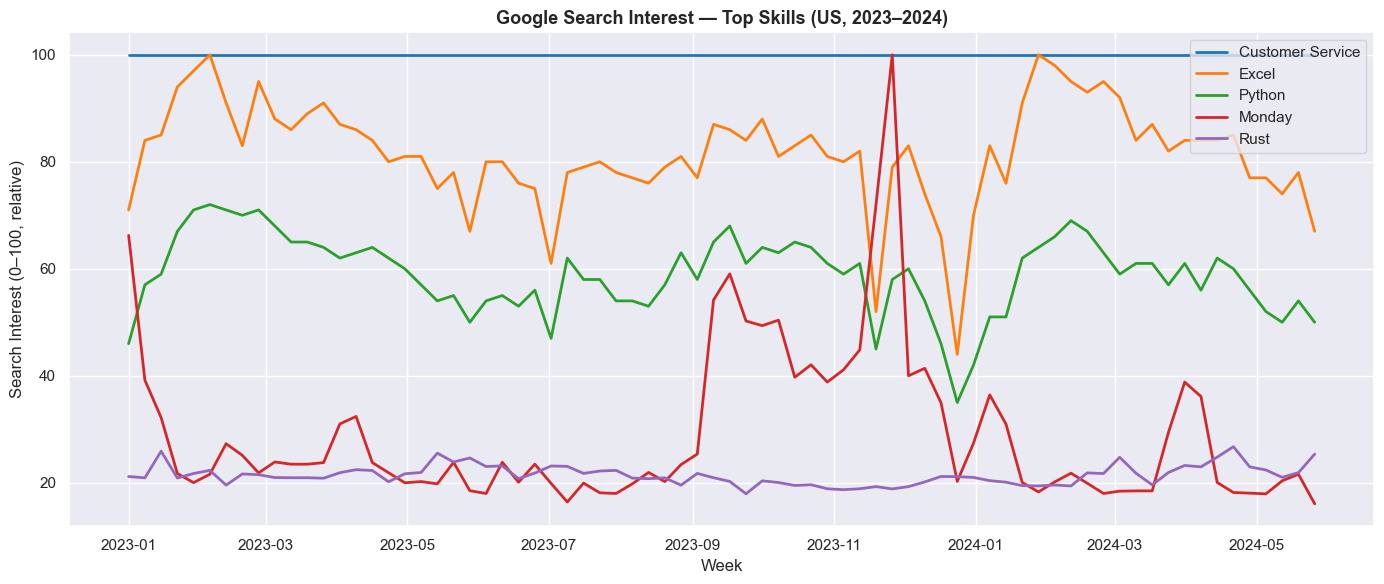

In [13]:
if not trends_skills.empty:
    fig, ax = plt.subplots(figsize=(14, 6))

    colors = plt.cm.tab10.colors
    top5 = trends_skills.mean().nlargest(5).index.tolist()

    for i, skill in enumerate(top5):
        ax.plot(
            trends_skills.index,
            trends_skills[skill],
            label=skill.title(),
            color=colors[i],
            linewidth=2,
        )

    ax.set_title('Google Search Interest — Top Skills (US, 2023–2024)', fontweight='bold', fontsize=13)
    ax.set_ylabel('Search Interest (0–100, relative)')
    ax.set_xlabel('Week')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
else:
    print('No trends data to plot — run cells above first')

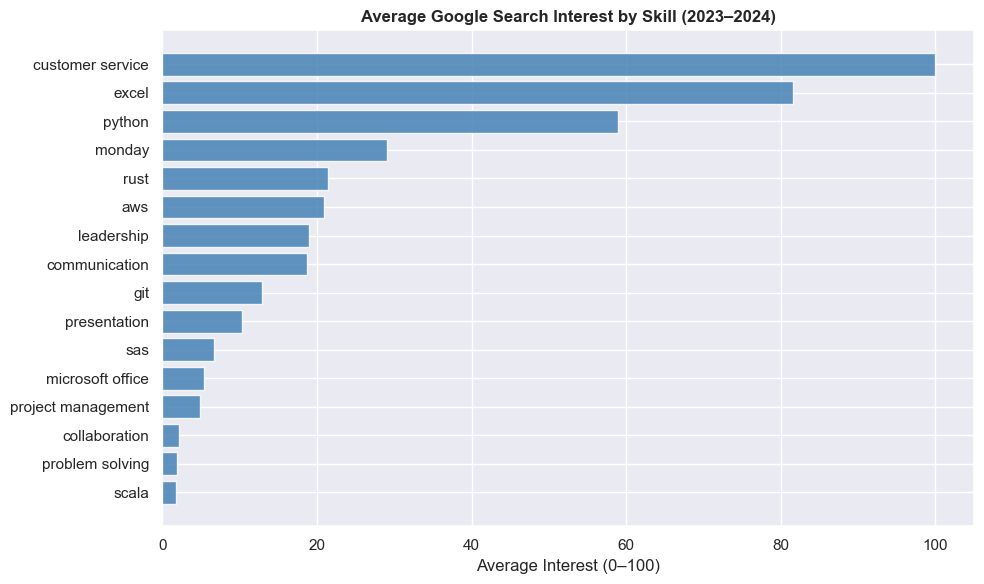

customer service      100.000000
excel                  81.635135
python                 58.891892
monday                 29.098293
rust                   21.439144
aws                    20.972973
leadership             19.000000
communication          18.729730
git                    12.935354
presentation           10.346089
sas                     6.727786
microsoft office        5.421823
project management      4.875359
collaboration           2.150685
problem solving         1.889685
scala                   1.817071


In [14]:
# Average interest ranking
if not trends_skills.empty:
    avg_interest = trends_skills.mean().sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(avg_interest.index, avg_interest.values, color='steelblue', alpha=0.85)
    plt.title('Average Google Search Interest by Skill (2023–2024)', fontweight='bold')
    plt.xlabel('Average Interest (0–100)')
    plt.tight_layout()
    plt.show()
    print(avg_interest.sort_values(ascending=False).to_string())

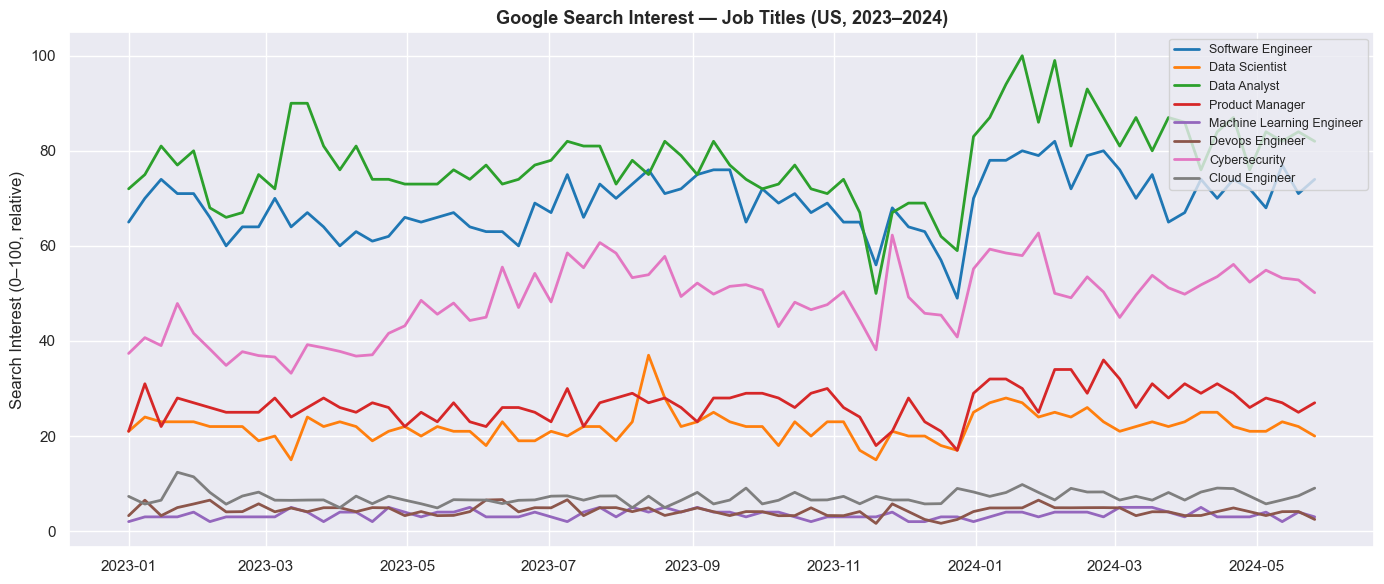

In [15]:
# Job title trends
if not trends_titles.empty:
    fig, ax = plt.subplots(figsize=(14, 6))
    colors = plt.cm.tab10.colors
    for i, col in enumerate(trends_titles.columns[:8]):
        ax.plot(trends_titles.index, trends_titles[col],
                label=col.replace(' jobs', '').title(),
                color=colors[i % 10], linewidth=2)
    ax.set_title('Google Search Interest — Job Titles (US, 2023–2024)', fontweight='bold', fontsize=13)
    ax.set_ylabel('Search Interest (0–100, relative)')
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

In [16]:
# Correlation: Google interest vs listing count per skill 
if not trends_skills.empty and not skill_weekly.empty:
    corr_results = []
    for skill in trends_skills.columns:
        skill_trend = trends_skills[[skill]].copy()
        skill_trend.index = pd.to_datetime(skill_trend.index)

        skill_vol = skill_weekly[skill_weekly['skill'] == skill].set_index('week')['listing_count']
        skill_vol.index = pd.to_datetime(skill_vol.index)

        merged = skill_trend.join(skill_vol, how='inner')
        if len(merged) >= 5:
            corr = merged[skill].corr(merged['listing_count'])
            corr_results.append({'skill': skill, 'correlation': round(corr, 3)})

    if corr_results:                          # ← only sort if we got results
        corr_df = pd.DataFrame(corr_results).sort_values('correlation', ascending=False)
        print('Correlation: Google Search Interest vs Job Listing Count')
        print(corr_df.to_string(index=False))
    else:
        print('   No correlation results — skill_weekly has no overlap with trends data.')
        print('   This is expected if listed_week is not in cleaned_jobs2.csv yet.')
        print('   Re-run finals.ipynb first, then re-run google_trends.ipynb.')

else:
    if skill_weekly.empty:
        print('   skill_weekly is empty — listed_week column not in cleaned_jobs2.csv.')
        print('   Re-run finals.ipynb to add time features, then retry.')
    else:
        print('   No trends data available.')

   No correlation results — skill_weekly has no overlap with trends data.
   This is expected if listed_week is not in cleaned_jobs2.csv yet.
   Re-run finals.ipynb first, then re-run google_trends.ipynb.


## 8. Export Combined Dataset

In [17]:
# Save trends as long format for Streamlit
if not trends_skills.empty:
    trends_long = (
        trends_skills
        .reset_index()
        .melt(id_vars='date', var_name='skill', value_name='interest')
    )
    trends_long['type'] = 'skill'
    trends_long.to_csv('data/trends_combined.csv', index=False)
    print(f'Saved data/trends_combined.csv  ({trends_long.shape})')
    print(trends_long.head())

if not trends_titles.empty:
    titles_long = (
        trends_titles
        .reset_index()
        .melt(id_vars='date', var_name='skill', value_name='interest')
    )
    titles_long['type'] = 'job_title'
    titles_long.to_csv('data/trends_jobtitles_long.csv', index=False)
    print(f'Saved data/trends_jobtitles_long.csv  ({titles_long.shape})')

print('\n  All trend data saved. Run streamlit run ap.py to see the dashboard.')

Saved data/trends_combined.csv  ((1184, 4))
        date   skill  interest   type
0 2023-01-01  python      46.0  skill
1 2023-01-08  python      57.0  skill
2 2023-01-15  python      59.0  skill
3 2023-01-22  python      67.0  skill
4 2023-01-29  python      71.0  skill
Saved data/trends_jobtitles_long.csv  ((740, 4))

  All trend data saved. Run streamlit run ap.py to see the dashboard.


---
## Summary

| Output file | Contents |
|---|---|
| `data/trends_skills.csv` | Weekly Google interest (0-100) per skill |
| `data/trends_jobtitles.csv` | Weekly Google interest per job title search |
| `data/trends_combined.csv` | Long format — skills trends for Streamlit |
| `data/trends_jobtitles_long.csv` | Long format — title trends for Streamlit |
| `data/skill_weekly_listings.csv` | Actual listing counts per skill per week |